# 04 - Evaluating and Comparing the Models

**Goal:** measure how good each model is *at catching attacks*, using metrics that are honest under class imbalance, then pick a winner.

**Metrics we use (and why):**
- **Confusion matrix** - the raw counts of right/wrong for each class.
- **Recall** - of all real attacks, how many we caught. *The gatekeeper in security.*
- **Precision** - of the alerts we raised, how many were real. (Analyst trust.)
- **F1** - one number balancing precision and recall.
- **AUPRC** - overall quality across all alert thresholds, focused on the rare attack class. **This is our primary deciding metric.**

We deliberately do **not** decide on accuracy - under imbalance it is misleading.

## Load the data and the trained models

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, precision_score, recall_score,
                             f1_score, average_precision_score, PrecisionRecallDisplay)

PROJECT_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "outputs", "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "outputs", "models")
FIG_DIR = os.path.join(PROJECT_ROOT, "outputs", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

data = joblib.load(os.path.join(PROCESSED_DIR, "train_test_data.joblib"))
X_test, y_test = data["X_test"], data["y_test"]

logreg = joblib.load(os.path.join(MODELS_DIR, "logreg.joblib"))
rf = joblib.load(os.path.join(MODELS_DIR, "random_forest.joblib"))

models = {"Logistic Regression": logreg, "Random Forest": rf}
print("Loaded test set:", X_test.shape[0], "rows, and 2 models.")

Loaded test set: 149333 rows, and 2 models.


## Confusion matrices

Each grid shows, on the test set, how many flows landed in each box. The dangerous box is **bottom-left in our layout: actual attack predicted benign (a missed attack / False Negative)**. We want that number small.

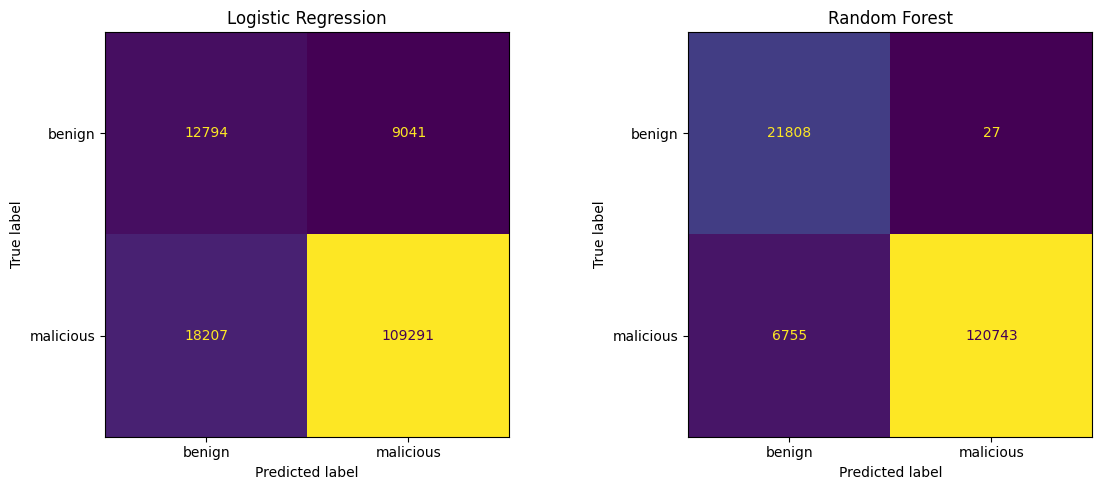

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["benign", "malicious"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "confusion_matrices.png"), dpi=150, bbox_inches="tight")
plt.show()

## The key numbers per model

`classification_report` prints precision, recall and F1 for each class. Focus on the **`malicious` (1)** row - that is the attack-catching performance.

In [3]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print("="*55)
    print(name)
    print("="*55)
    print(classification_report(y_test, y_pred, target_names=["benign (0)", "malicious (1)"]))

Logistic Regression
               precision    recall  f1-score   support

   benign (0)       0.41      0.59      0.48     21835
malicious (1)       0.92      0.86      0.89    127498

     accuracy                           0.82    149333
    macro avg       0.67      0.72      0.69    149333
 weighted avg       0.85      0.82      0.83    149333

Random Forest
               precision    recall  f1-score   support

   benign (0)       0.76      1.00      0.87     21835
malicious (1)       1.00      0.95      0.97    127498

     accuracy                           0.95    149333
    macro avg       0.88      0.97      0.92    149333
 weighted avg       0.97      0.95      0.96    149333



## Precision-Recall curves and AUPRC (the deciding metric)

A model outputs a *probability* of malicious; we choose a threshold to turn that into an alert. The PR curve shows precision vs recall across **every** possible threshold. The area under it (**AUPRC**) is a single fair score for the whole curve, focused on the rare class. Higher = better. The dashed line is the 'no-skill' baseline (= the attack rate).

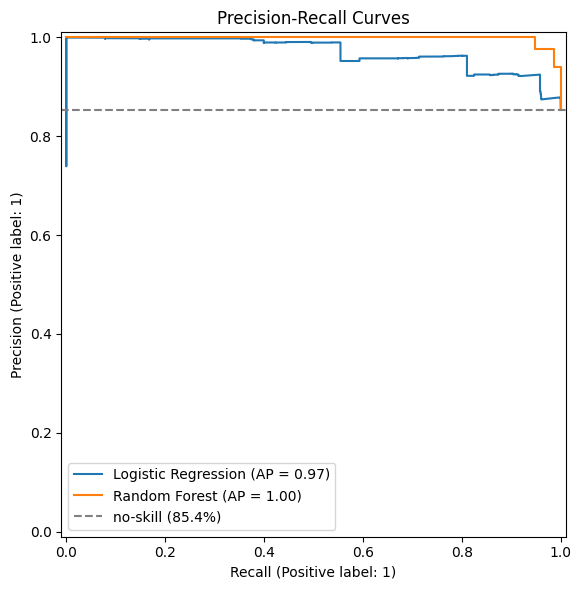

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in models.items():
    y_scores = model.predict_proba(X_test)[:, 1]   # probability of "malicious"
    PrecisionRecallDisplay.from_predictions(y_test, y_scores, name=name, ax=ax)

baseline = y_test.mean()
ax.axhline(baseline, linestyle="--", color="grey", label=f"no-skill ({baseline:.1%})")
ax.set_title("Precision-Recall Curves")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "precision_recall_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

## Side-by-side comparison and the winner

We collect every metric into one table. **The winner is chosen on AUPRC, confirmed by recall and F1** - not accuracy. The winning model is the one we take forward to the SHAP explainability stage (notebook 05).

In [6]:
rows = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_scores = model.predict_proba(X_test)[:, 1]
    rows.append({
        "Model": name,
        "Accuracy (report only)": round((y_pred == y_test).mean(), 3),
        "Precision": round(precision_score(y_test, y_pred), 3),
        "Recall": round(recall_score(y_test, y_pred), 3),
        "F1": round(f1_score(y_test, y_pred), 3),
        "AUPRC": round(average_precision_score(y_test, y_scores), 3),
    })

results = pd.DataFrame(rows).set_index("Model")
print(results.to_string())

winner = results["AUPRC"].idxmax()
print(f"\nWinner by AUPRC: {winner}")
print("-> This model goes to notebook 05 for SHAP explainability.")
results.to_csv(os.path.join(PROJECT_ROOT, "outputs", "model_comparison.csv"))
print("\nSaved comparison table to outputs/model_comparison.csv.")

                     Accuracy (report only)  Precision  Recall     F1  AUPRC
Model                                                                       
Logistic Regression                   0.818      0.924   0.857  0.889  0.970
Random Forest                         0.955      1.000   0.947  0.973  0.998

Winner by AUPRC: Random Forest
-> This model goes to notebook 05 for SHAP explainability.

Saved comparison table to outputs/model_comparison.csv.
